# Notebook 4: Hybrid Integration & Sparsity (Phase 4, Cells 20-24)

Protocol D enhanced hybrid loop:
- Popular items: Sarwar item-based CF
- Niche / rated-cold items: quantum kernel clusters
- Extreme cold items (<5 ratings): content-based matching from genre profile

Also includes long-tail metrics (coverage, Gini, diversity) and sparsity simulations from 20% to 95%.

Required outputs:
- `hybrid_recs.csv`
- `comparison_table.csv`

In [5]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, load_npz
from sklearn.metrics.pairwise import cosine_similarity

PHASE1_DIR = Path("data/processed_32m_phase1")
PHASE2_DIR = Path("data/processed_32m_phase2")
PHASE3_DIR = Path("data/processed_32m_phase3")
OUTPUT_DIR = Path("data/processed_32m_phase4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RATINGS_PATH = PHASE1_DIR / "ratings_sparse.npz"
IDMAP_PATH = PHASE1_DIR / "id_mappings.pkl"
BASELINE_PATH = PHASE2_DIR / "baseline_metrics.csv"
CLASSICAL_CLUSTERS_PATH = PHASE2_DIR / "classical_clusters.npy"
QUANTUM_LABELS_PATH = PHASE3_DIR / "quantum_labels.npy"
KERNEL_PATH = PHASE3_DIR / "kernel_matrix.npz"
MOVIES_PATH = Path("data/ml-32m/movies.csv")

SEED = 42
TOPN = 10
EVAL_USERS = 300
POPULAR_QUANTILE = 0.80
EXTREME_COLD_MAX_RATINGS = 5
POPULAR_TOP_ITEMS = 1500
POPULAR_TOP_NEIGHBORS = 40
CANDIDATE_POOL = 3000
SPARSITY_DROPS = [0.20, 0.40, 0.60, 0.80, 0.90, 0.95]

ratings_csr = load_npz(RATINGS_PATH).tocsr().astype(np.float32)
with open(IDMAP_PATH, "rb") as f:
    idmap = pickle.load(f)

unique_users = idmap["unique_users"]
unique_items = idmap["unique_items"]

baseline_df = pd.read_csv(BASELINE_PATH) if BASELINE_PATH.exists() else pd.DataFrame()
classical_clusters = np.load(CLASSICAL_CLUSTERS_PATH).astype(np.int32) if CLASSICAL_CLUSTERS_PATH.exists() else None
quantum_labels = np.load(QUANTUM_LABELS_PATH).astype(np.int32)
kernel_npz = np.load(KERNEL_PATH)
sample_idx = kernel_npz["sample_idx"].astype(np.int32)

item_support = np.asarray((ratings_csr != 0).sum(axis=0)).ravel().astype(np.int32)
n_users, n_items = ratings_csr.shape

print(f"ratings shape: {ratings_csr.shape}")
print(f"quantum label sample size: {len(quantum_labels)}")
print(f"classical clusters available: {classical_clusters is not None}")

ratings shape: (200948, 84432)
quantum label sample size: 300
classical clusters available: True


In [6]:
# Cell 22: Prepare Protocol D components (popular / niche / extreme-cold)
rng = np.random.default_rng(SEED)

popular_threshold = int(np.quantile(item_support[item_support > 0], POPULAR_QUANTILE)) if np.any(item_support > 0) else 1
popular_mask = item_support >= popular_threshold
extreme_cold_mask = item_support < EXTREME_COLD_MAX_RATINGS
niche_mask = (~popular_mask) & (~extreme_cold_mask)

top_candidates = np.argsort(item_support)[::-1][: min(CANDIDATE_POOL, n_items)]
popular_items = np.where(popular_mask)[0]

movies = pd.read_csv(MOVIES_PATH, usecols=["movieId", "genres"])
movies = movies[movies["movieId"].isin(unique_items)].copy()
movie_to_idx = {int(mid): int(i) for i, mid in enumerate(unique_items.tolist())}
movies["item_idx"] = movies["movieId"].map(movie_to_idx)
movies = movies.dropna(subset=["item_idx"]).copy()
movies["item_idx"] = movies["item_idx"].astype(int)
movies["genres"] = movies["genres"].fillna("(no genres listed)")
genre_table = movies["genres"].str.get_dummies(sep="|")
genre_table.index = movies["item_idx"]
genre_table = genre_table.groupby(level=0).max()
genre_table = genre_table.reindex(np.arange(n_items), fill_value=0)
genre_matrix = genre_table.to_numpy(dtype=np.float32, copy=False)

pop_items = np.argsort(item_support)[::-1][: min(POPULAR_TOP_ITEMS, n_items)]
pop_item_to_local = {int(g): int(l) for l, g in enumerate(pop_items)}
ratings_pop = ratings_csr[:, pop_items].tocsr().astype(np.float32)

user_nnz = np.diff(ratings_pop.indptr)
user_sums = np.asarray(ratings_pop.sum(axis=1)).ravel()
user_means = np.divide(user_sums, user_nnz, out=np.zeros_like(user_sums, dtype=np.float32), where=user_nnz > 0).astype(np.float32)
global_user_mean = float(np.mean(user_means[user_nnz > 0])) if np.any(user_nnz > 0) else 3.5

rows, cols = ratings_pop.nonzero()
centered_data = ratings_pop.data - user_means[rows]
centered = csr_matrix((centered_data, (rows, cols)), shape=ratings_pop.shape, dtype=np.float32)
gram = (centered.T @ centered).toarray().astype(np.float32)
norms = np.sqrt(np.diag(gram)) + 1e-8
item_sim = gram / (norms[:, None] * norms[None, :])
np.fill_diagonal(item_sim, 0.0)

sampled_user_latent = np.load(PHASE1_DIR / "latent_embeddings.npy")[sample_idx].astype(np.float32)
q_clusters = np.unique(quantum_labels)
q_centroids = []
for qc in q_clusters:
    members = sampled_user_latent[quantum_labels == qc]
    q_centroids.append(members.mean(axis=0))
q_centroids = np.vstack(q_centroids).astype(np.float32)

all_latent = np.load(PHASE1_DIR / "latent_embeddings.npy").astype(np.float32)
dist_to_q = ((all_latent[:, None, :] - q_centroids[None, :, :]) ** 2).sum(axis=2)
user_q_assign = np.argmin(dist_to_q, axis=1).astype(np.int32)

q_item_means = np.zeros((len(q_clusters), n_items), dtype=np.float32)
for i, qc in enumerate(q_clusters):
    user_ids = sample_idx[quantum_labels == qc]
    if len(user_ids) > 0:
        q_item_means[i] = ratings_csr[user_ids].mean(axis=0).A1.astype(np.float32)

print(f"popular threshold (#ratings): {popular_threshold}")
print(f"popular items: {popular_mask.sum()} | niche: {niche_mask.sum()} | extreme-cold: {extreme_cold_mask.sum()}")
print(f"genre features: {genre_matrix.shape[1]}")

popular threshold (#ratings): 43
popular items: 16993 | niche: 26891 | extreme-cold: 40548
genre features: 20


In [7]:
# Cell 23: Hybrid Protocol D recommendation loop + long-tail metrics
def score_popular_item(user_idx, item_idx, seen_items):
    _ = seen_items
    if item_idx not in pop_item_to_local:
        return np.nan
    local_target = pop_item_to_local[item_idx]

    start, end = ratings_pop.indptr[user_idx], ratings_pop.indptr[user_idx + 1]
    user_local_items = ratings_pop.indices[start:end]
    user_vals = ratings_pop.data[start:end]

    if len(user_local_items) == 0:
        return global_user_mean

    sims = item_sim[local_target, user_local_items]
    if len(sims) == 0:
        return global_user_mean

    order = np.argsort(np.abs(sims))[::-1][:POPULAR_TOP_NEIGHBORS]
    sims_sel = sims[order]
    vals_sel = user_vals[order]
    u_mean = user_means[user_idx] if user_nnz[user_idx] > 0 else global_user_mean
    denom = np.sum(np.abs(sims_sel)) + 1e-8
    pred = u_mean + float(np.dot(sims_sel, (vals_sel - u_mean)) / denom)
    return float(np.clip(pred, 0.5, 5.0))


def score_quantum_cluster(user_idx, item_idx):
    qc = user_q_assign[user_idx]
    return float(np.clip(q_item_means[qc, item_idx], 0.5, 5.0))


def score_content_genre(user_idx, item_idx, seen_items):
    _ = user_idx
    if len(seen_items) == 0:
        return 0.0
    seen_idx = np.fromiter(seen_items, dtype=np.int32)
    profile = genre_matrix[seen_idx].mean(axis=0)
    num = float(np.dot(profile, genre_matrix[item_idx]))
    den = float((np.linalg.norm(profile) * np.linalg.norm(genre_matrix[item_idx])) + 1e-8)
    return float(num / den)


def hybrid_recommend_for_user(user_idx, seen_items, topn=10):
    candidate_items = [i for i in top_candidates if i not in seen_items]

    scored = []
    for item_idx in candidate_items:
        if popular_mask[item_idx]:
            score = score_popular_item(user_idx, item_idx, seen_items)
            strategy = "sarwar_item_cf"
        elif niche_mask[item_idx]:
            score = score_quantum_cluster(user_idx, item_idx)
            strategy = "quantum_kernel_cluster"
        else:
            score = score_content_genre(user_idx, item_idx, seen_items)
            strategy = "content_genre_profile"

        if np.isnan(score):
            continue
        scored.append((int(item_idx), float(score), strategy))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:topn]


def gini_from_counts(counts):
    x = np.asarray(counts, dtype=np.float64)
    if np.sum(x) == 0:
        return 0.0
    x_sorted = np.sort(x)
    n = len(x_sorted)
    return float((2.0 * np.sum((np.arange(1, n + 1) * x_sorted)) / (n * np.sum(x_sorted))) - (n + 1) / n)


def average_intra_list_diversity(recommendations):
    diversities = []
    for rec in recommendations:
        items = [r["item_idx"] for r in rec]
        if len(items) < 2:
            continue
        gm = genre_matrix[np.array(items, dtype=np.int32)]
        sim_mat = cosine_similarity(gm)
        iu = np.triu_indices_from(sim_mat, k=1)
        if len(iu[0]) == 0:
            continue
        mean_sim = float(np.mean(sim_mat[iu]))
        diversities.append(1.0 - mean_sim)
    return float(np.mean(diversities)) if diversities else 0.0


eligible_users = np.where(np.diff(ratings_csr.indptr) >= 3)[0]
eval_users = rng.choice(eligible_users, size=min(EVAL_USERS, len(eligible_users)), replace=False)

hybrid_rows = []
hybrid_lists = []
hits, ndcgs, precisions = [], [], []

for u in eval_users:
    start, end = ratings_csr.indptr[u], ratings_csr.indptr[u + 1]
    seen = ratings_csr.indices[start:end]
    seen_set = set(seen.tolist())

    held_out = int(rng.choice(seen))
    train_seen = set(seen_set)
    train_seen.discard(held_out)

    recs = hybrid_recommend_for_user(int(u), train_seen, topn=TOPN)
    hybrid_lists.append([{"item_idx": r[0], "score": r[1], "strategy": r[2]} for r in recs])

    rec_items = [r[0] for r in recs]
    hit = 1.0 if held_out in rec_items else 0.0
    hits.append(hit)
    precisions.append(hit / TOPN)
    if hit:
        rank = rec_items.index(held_out) + 1
        ndcgs.append(float(1.0 / np.log2(rank + 1)))
    else:
        ndcgs.append(0.0)

    user_id = int(unique_users[u]) if u < len(unique_users) else int(u)
    for rank, (item_idx, score, strategy) in enumerate(recs, start=1):
        movie_id = int(unique_items[item_idx]) if item_idx < len(unique_items) else int(item_idx)
        hybrid_rows.append({
            "user_idx": int(u),
            "user_id": user_id,
            "item_idx": int(item_idx),
            "movie_id": movie_id,
            "rank": int(rank),
            "score": float(score),
            "strategy": strategy,
        })

hybrid_recs_df = pd.DataFrame(hybrid_rows)

rec_item_counts = hybrid_recs_df["item_idx"].value_counts().reindex(np.arange(n_items), fill_value=0).values
coverage = float((hybrid_recs_df["item_idx"].nunique()) / n_items) if n_items > 0 else 0.0
gini = gini_from_counts(rec_item_counts)
diversity = average_intra_list_diversity(hybrid_lists)

hybrid_metrics_row = {
    "model": "hybrid_protocol_d",
    "hr@10": float(np.mean(hits)) if hits else 0.0,
    "ndcg@10": float(np.mean(ndcgs)) if ndcgs else 0.0,
    "precision@10": float(np.mean(precisions)) if precisions else 0.0,
    "coverage": coverage,
    "gini": gini,
    "diversity": diversity,
    "sparsity_drop": 0.0,
}

print(hybrid_recs_df.head())
print(pd.DataFrame([hybrid_metrics_row]))

   user_idx  user_id  item_idx  movie_id  rank     score        strategy
0    102986   102987     13361     68954     1  4.645746  sarwar_item_cf
1    102986   102987     42951    168252     2  4.635705  sarwar_item_cf
2    102986   102987     12221     58559     3  4.634508  sarwar_item_cf
3    102986   102987     47388    177765     4  4.631137  sarwar_item_cf
4    102986   102987      2941      3034     5  4.622514  sarwar_item_cf
               model  hr@10  ndcg@10  precision@10  coverage      gini  \
0  hybrid_protocol_d   0.02  0.00978         0.002  0.010328  0.993464   

   diversity  sparsity_drop  
0   0.593403            0.0  


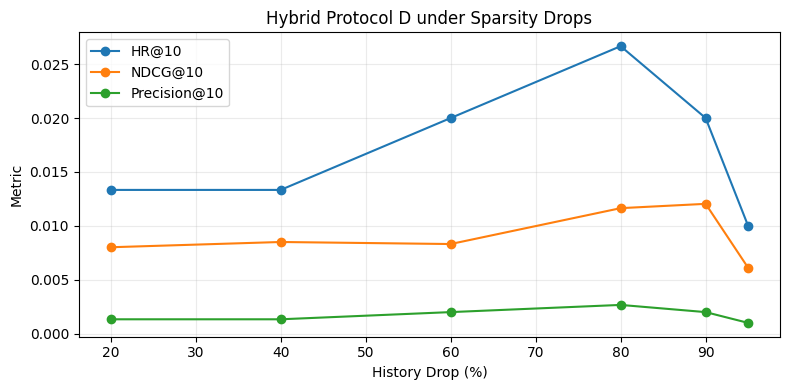

Saved outputs:
- data\processed_32m_phase4\hybrid_recs.csv
- data\processed_32m_phase4\comparison_table.csv

                                  model     hr@10   ndcg@10  precision@10  \
0                          kmeans_lloyd  0.163000  0.095647      0.016300   
1  item_cf_adjusted_cosine_weighted_sum  0.024000  0.012973      0.002400   
2                     hybrid_protocol_d  0.020000  0.009780      0.002000   
3                     hybrid_protocol_d  0.013333  0.008015      0.001333   
4                     hybrid_protocol_d  0.013333  0.008503      0.001333   
5                     hybrid_protocol_d  0.020000  0.008314      0.002000   
6                     hybrid_protocol_d  0.026667  0.011642      0.002667   
7                     hybrid_protocol_d  0.020000  0.012042      0.002000   
8                     hybrid_protocol_d  0.010000  0.006111      0.001000   

   coverage      gini  diversity  sparsity_drop  
0       NaN       NaN        NaN           0.00  
1       NaN       Na

In [8]:
# Cell 24: Sparsity simulations (20%-95% drops) + save required outputs
def evaluate_with_history_drop(drop_fraction):
    rng_local = np.random.default_rng(SEED + int(drop_fraction * 1000))
    hits_local, ndcgs_local, prec_local = [], [], []

    for u in eval_users:
        start, end = ratings_csr.indptr[u], ratings_csr.indptr[u + 1]
        seen = ratings_csr.indices[start:end]
        if len(seen) < 3:
            continue

        held_out = int(rng_local.choice(seen))
        train_seen = [x for x in seen.tolist() if x != held_out]

        if len(train_seen) > 1:
            keep_n = max(1, int(np.ceil((1.0 - drop_fraction) * len(train_seen))))
            keep_idx = rng_local.choice(np.arange(len(train_seen)), size=keep_n, replace=False)
            sparse_seen = set(np.array(train_seen)[keep_idx].tolist())
        else:
            sparse_seen = set(train_seen)

        recs = hybrid_recommend_for_user(int(u), sparse_seen, topn=TOPN)
        rec_items = [r[0] for r in recs]

        hit = 1.0 if held_out in rec_items else 0.0
        hits_local.append(hit)
        prec_local.append(hit / TOPN)
        if hit:
            rank = rec_items.index(held_out) + 1
            ndcgs_local.append(float(1.0 / np.log2(rank + 1)))
        else:
            ndcgs_local.append(0.0)

    return {
        "model": "hybrid_protocol_d",
        "hr@10": float(np.mean(hits_local)) if hits_local else 0.0,
        "ndcg@10": float(np.mean(ndcgs_local)) if ndcgs_local else 0.0,
        "precision@10": float(np.mean(prec_local)) if prec_local else 0.0,
        "coverage": np.nan,
        "gini": np.nan,
        "diversity": np.nan,
        "sparsity_drop": float(drop_fraction),
    }


sparsity_rows = [evaluate_with_history_drop(d) for d in SPARSITY_DROPS]

baseline_comp = baseline_df.copy()
if not baseline_comp.empty:
    rename_map = {}
    if "model" not in baseline_comp.columns and "Model" in baseline_comp.columns:
        rename_map["Model"] = "model"
    if "hr_at_10" in baseline_comp.columns:
        rename_map["hr_at_10"] = "hr@10"
    if "ndcg_at_10" in baseline_comp.columns:
        rename_map["ndcg_at_10"] = "ndcg@10"
    if "precision_at_10" in baseline_comp.columns:
        rename_map["precision_at_10"] = "precision@10"
    baseline_comp = baseline_comp.rename(columns=rename_map)

    for col in ["model", "hr@10", "ndcg@10", "precision@10"]:
        if col not in baseline_comp.columns:
            baseline_comp[col] = np.nan

    baseline_comp = baseline_comp[["model", "hr@10", "ndcg@10", "precision@10"]].copy()
    baseline_comp["coverage"] = np.nan
    baseline_comp["gini"] = np.nan
    baseline_comp["diversity"] = np.nan
    baseline_comp["sparsity_drop"] = 0.0

comparison_table = pd.concat(
    [
        baseline_comp,
        pd.DataFrame([hybrid_metrics_row]),
        pd.DataFrame(sparsity_rows),
    ],
    ignore_index=True,
)

hybrid_recs_df.to_csv(OUTPUT_DIR / "hybrid_recs.csv", index=False)
comparison_table.to_csv(OUTPUT_DIR / "comparison_table.csv", index=False)

sparsity_df = pd.DataFrame(sparsity_rows)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["hr@10"], marker="o", label="HR@10")
ax.plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["ndcg@10"], marker="o", label="NDCG@10")
ax.plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["precision@10"], marker="o", label="Precision@10")
ax.set_title("Hybrid Protocol D under Sparsity Drops")
ax.set_xlabel("History Drop (%)")
ax.set_ylabel("Metric")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

print("Saved outputs:")
print(f"- {OUTPUT_DIR / 'hybrid_recs.csv'}")
print(f"- {OUTPUT_DIR / 'comparison_table.csv'}")
print("")
print(comparison_table.head(12))

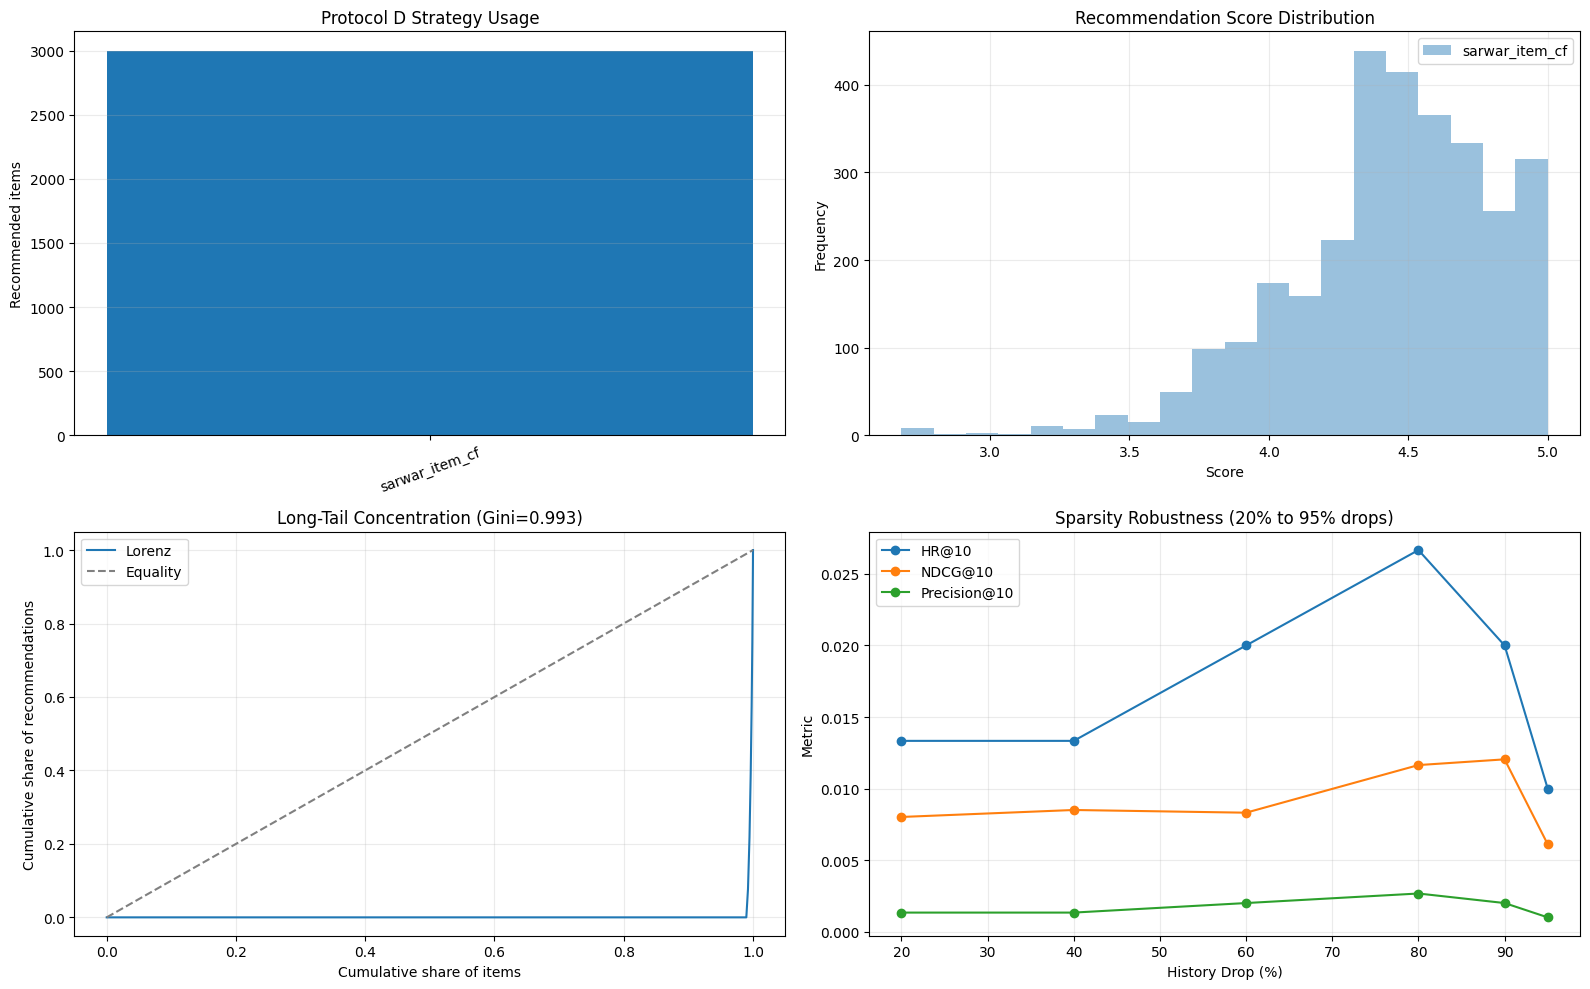

Strategy-level score summary:
         strategy  count      mean       std       min  max
0  sarwar_item_cf   3000  4.436578  0.370581  2.682144  5.0


In [9]:
# Cell 25: Additional visualizations for interpretability

fig, axes = plt.subplots(2, 2, figsize=(16, 10))



# 1) Strategy usage in final recommendations

strategy_counts = hybrid_recs_df["strategy"].value_counts()

axes[0, 0].bar(strategy_counts.index, strategy_counts.values)

axes[0, 0].set_title("Protocol D Strategy Usage")

axes[0, 0].set_ylabel("Recommended items")

axes[0, 0].tick_params(axis="x", labelrotation=20)

axes[0, 0].grid(axis="y", alpha=0.25)



# 2) Score distributions by strategy

for strategy, group in hybrid_recs_df.groupby("strategy"):

    axes[0, 1].hist(group["score"].values, bins=20, alpha=0.45, label=strategy)

axes[0, 1].set_title("Recommendation Score Distribution")

axes[0, 1].set_xlabel("Score")

axes[0, 1].set_ylabel("Frequency")

axes[0, 1].legend()

axes[0, 1].grid(alpha=0.25)



# 3) Long-tail concentration via Lorenz curve (with Gini)

rec_counts = hybrid_recs_df["item_idx"].value_counts().reindex(np.arange(n_items), fill_value=0).values.astype(np.float64)

sorted_counts = np.sort(rec_counts)

cum_items = np.linspace(0, 1, len(sorted_counts) + 1)

cum_recs = np.concatenate([[0.0], np.cumsum(sorted_counts)])

cum_recs = cum_recs / (cum_recs[-1] if cum_recs[-1] > 0 else 1.0)

axes[1, 0].plot(cum_items, cum_recs, label="Lorenz")

axes[1, 0].plot([0, 1], [0, 1], "--", color="gray", label="Equality")

axes[1, 0].set_title(f"Long-Tail Concentration (Gini={gini:.3f})")

axes[1, 0].set_xlabel("Cumulative share of items")

axes[1, 0].set_ylabel("Cumulative share of recommendations")

axes[1, 0].legend()

axes[1, 0].grid(alpha=0.25)



# 4) Sparsity simulation with all ranking metrics

axes[1, 1].plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["hr@10"], marker="o", label="HR@10")

axes[1, 1].plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["ndcg@10"], marker="o", label="NDCG@10")

axes[1, 1].plot(sparsity_df["sparsity_drop"] * 100, sparsity_df["precision@10"], marker="o", label="Precision@10")

axes[1, 1].set_title("Sparsity Robustness (20% to 95% drops)")

axes[1, 1].set_xlabel("History Drop (%)")

axes[1, 1].set_ylabel("Metric")

axes[1, 1].legend()

axes[1, 1].grid(alpha=0.25)



plt.tight_layout()

plt.show()



# Quick summary table for strategy-level behavior

strategy_summary = (

    hybrid_recs_df.groupby("strategy")["score"]

    .agg(["count", "mean", "std", "min", "max"])

    .reset_index()

)

print("Strategy-level score summary:")

print(strategy_summary)